# NB - YOLO + CNN Baseline

Pipeline:
1. Load YOLO `best_yolo_v17.pt`
2. YOLO crop vùng bệnh từ dataset classification 5 lớp
3. Train CNN baseline đúng theo cấu trúc đã chọn:

```text
Conv2D(8) → MaxPool
Conv2D(16) → MaxPool
Flatten
Dense(32)
Dropout(0.5)
Softmax
```

4. Xuất learning curve, confusion matrix, classification report, metrics và zip kết quả.


In [1]:
# 1. INSTALL
!pip install -q ultralytics


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 33.2 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 95.8 MB/s eta 0:00:00:00:010:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible

In [2]:
# 2. IMPORT

import os
import io
import json
import shutil
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

from sklearn.metrics import confusion_matrix, classification_report

from ultralytics import YOLO
from ipywidgets import FileUpload
from IPython.display import display

print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))


2026-05-30 15:32:31.505912: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1780155151.726667      58 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1780155151.788868      58 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1780155152.340922      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780155152.340961      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780155152.340964      58 computation_placer.cc:177] computation placer alr

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
TensorFlow: 2.19.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


In [3]:
# 3. CONFIG

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

DATASET_PATH = "/kaggle/input/datasets/kimlonkkk/data10k-v2/split_dataset_backup_10k_v2"

# Tự tìm file YOLO .pt trong Kaggle Input
pt_files = []
for root, dirs, files in os.walk("/kaggle/input"):
    for f in files:
        if f.endswith(".pt"):
            pt_files.append(os.path.join(root, f))

print("Found .pt files:")
for i, p in enumerate(pt_files):
    print(i, ":", p)

if len(pt_files) == 0:
    raise FileNotFoundError("Không tìm thấy best_yolo_v17.pt trong /kaggle/input. Hãy add input YOLO trước.")

YOLO_MODEL_INDEX = 0
YOLO_MODEL_PATH = pt_files[YOLO_MODEL_INDEX]

IMG_SIZE = 224
BATCH_SIZE = 32
EPOCHS = 25

MODEL_NAME = "YOLO_CNN_Baseline"
OUT_DIR = f"/kaggle/working/{MODEL_NAME}_results"
CROP_DATASET_DIR = "/kaggle/working/yolo_crop_cnn_baseline_dataset"

os.makedirs(OUT_DIR, exist_ok=True)
os.makedirs(CROP_DATASET_DIR, exist_ok=True)

AUTOTUNE = tf.data.AUTOTUNE

print("Using YOLO:", YOLO_MODEL_PATH)


Found .pt files:
0 : /kaggle/input/datasets/kimlonkkk/best-yolo1/best_yolo_v17.pt
Using YOLO: /kaggle/input/datasets/kimlonkkk/best-yolo1/best_yolo_v17.pt


In [4]:
# 4. CHECK PATHS

print("DATASET_PATH exists:", os.path.exists(DATASET_PATH))
print("YOLO_MODEL_PATH exists:", os.path.exists(YOLO_MODEL_PATH))
print("Dataset folders:", os.listdir(DATASET_PATH))


DATASET_PATH exists: True
YOLO_MODEL_PATH exists: True
Dataset folders: ['val', 'test', 'train']


In [5]:
# 5. LOAD YOLO MODEL

yolo_model = YOLO(YOLO_MODEL_PATH)
print("YOLO classes:", yolo_model.names)


YOLO classes: {0: 'blight', 1: 'common_rust', 2: 'gray_spot', 3: 'health'}


In [6]:
# 6. CROP FUNCTION

def crop_with_yolo(image_path, yolo_model, conf_thres=0.25, img_size=224):
    image = Image.open(image_path).convert("RGB")
    w, h = image.size

    results = yolo_model.predict(
        source=str(image_path),
        conf=conf_thres,
        verbose=False
    )

    boxes = results[0].boxes

    if boxes is not None and len(boxes) > 0:
        confs = boxes.conf.cpu().numpy()
        best_idx = int(np.argmax(confs))
        x1, y1, x2, y2 = boxes.xyxy[best_idx].cpu().numpy()

        box_w = x2 - x1
        box_h = y2 - y1
        box_area = box_w * box_h
        img_area = w * h

        # Box quá nhỏ thì giữ ảnh gốc để tránh mất ngữ cảnh
        if box_area / img_area < 0.03:
            return image.resize((img_size, img_size))

        # Padding giữ thêm ngữ cảnh
        pad_x = int(box_w * 0.5)
        pad_y = int(box_h * 0.5)

        x1 = max(0, int(x1) - pad_x)
        y1 = max(0, int(y1) - pad_y)
        x2 = min(w, int(x2) + pad_x)
        y2 = min(h, int(y2) + pad_y)

        if x2 > x1 and y2 > y1:
            image = image.crop((x1, y1, x2, y2))

    return image.resize((img_size, img_size))


In [7]:
# 7. CREATE CROPPED DATASET

splits = ["train", "val", "test"]
image_exts = [".jpg", ".jpeg", ".png", ".bmp", ".webp"]

crop_stats = {"total": 0, "saved": 0, "errors": 0}

for split in splits:
    split_dir = Path(DATASET_PATH) / split

    for class_dir in split_dir.iterdir():
        if not class_dir.is_dir():
            continue

        class_name = class_dir.name
        out_class_dir = Path(CROP_DATASET_DIR) / split / class_name
        out_class_dir.mkdir(parents=True, exist_ok=True)

        image_paths = [p for p in class_dir.iterdir() if p.suffix.lower() in image_exts]
        print(f"Processing {split}/{class_name}: {len(image_paths)} images")

        for img_path in image_paths:
            crop_stats["total"] += 1
            try:
                cropped = crop_with_yolo(img_path, yolo_model, conf_thres=0.25, img_size=IMG_SIZE)
                cropped.save(out_class_dir / img_path.name)
                crop_stats["saved"] += 1
            except Exception as e:
                crop_stats["errors"] += 1
                print("Error:", img_path, e)

print("Crop stats:", crop_stats)
print("Saved at:", CROP_DATASET_DIR)


Processing train/common_rust: 1261 images
Processing train/not_corn_leaf: 1690 images
Processing train/blight: 1283 images
Processing train/healthy: 1173 images
Processing train/gray_spot: 1483 images
Processing val/common_rust: 270 images
Processing val/not_corn_leaf: 362 images
Processing val/blight: 275 images
Processing val/healthy: 251 images
Processing val/gray_spot: 317 images
Processing test/common_rust: 271 images
Processing test/not_corn_leaf: 363 images
Processing test/blight: 276 images
Processing test/healthy: 253 images
Processing test/gray_spot: 319 images
Crop stats: {'total': 9847, 'saved': 9847, 'errors': 0}
Saved at: /kaggle/working/yolo_crop_cnn_baseline_dataset


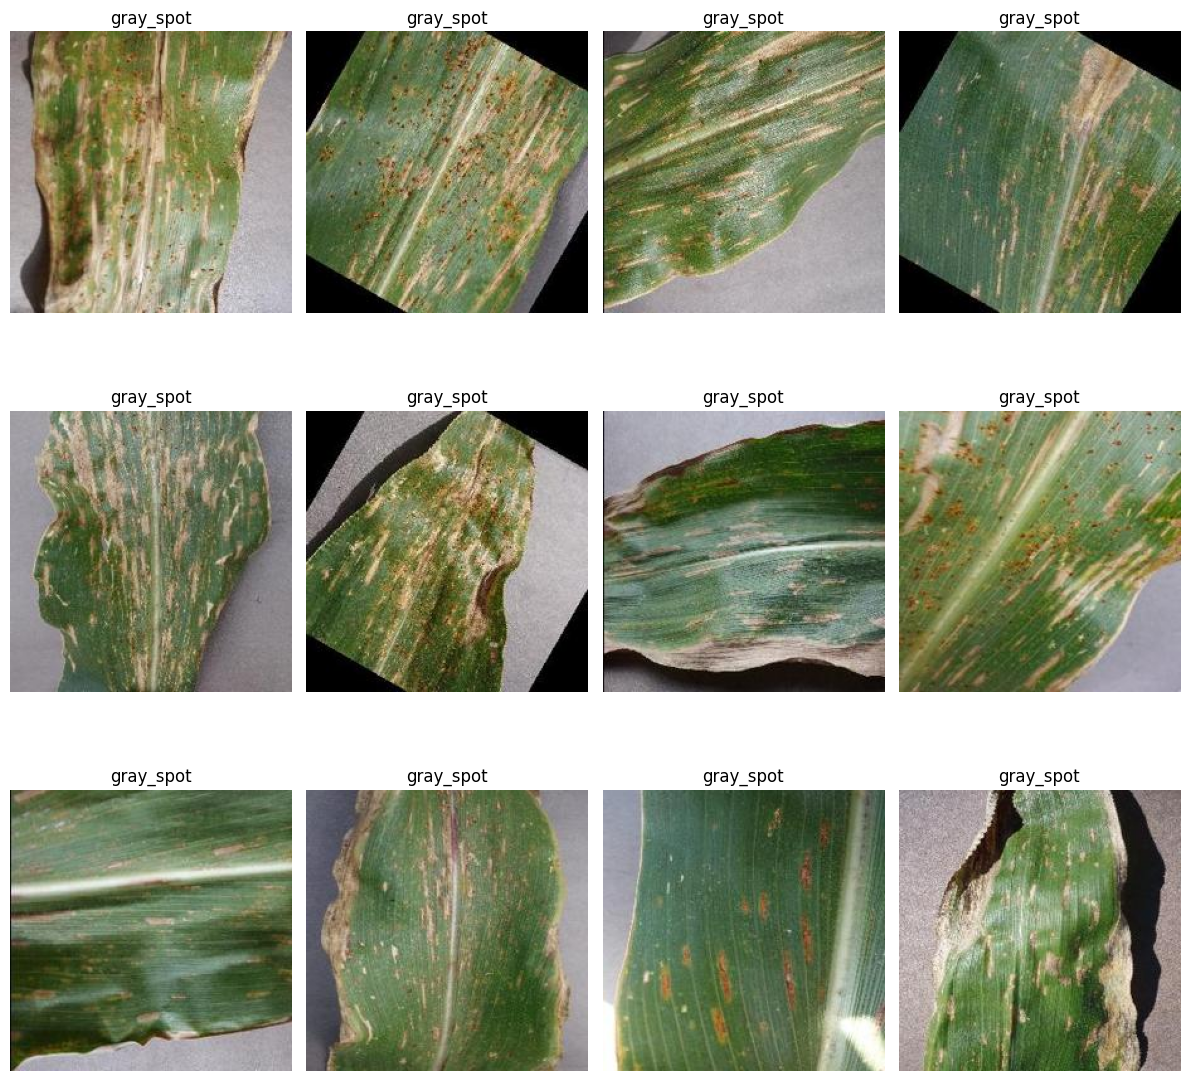

In [8]:
# 8. VISUALIZE CROPS

import glob

sample_images = glob.glob(CROP_DATASET_DIR + "/train/*/*")[:12]

plt.figure(figsize=(12, 12))

for i, img_path in enumerate(sample_images):
    img = Image.open(img_path).convert("RGB")
    plt.subplot(3, 4, i + 1)
    plt.imshow(img)
    plt.title(Path(img_path).parent.name)
    plt.axis("off")

plt.tight_layout()
plt.show()


In [9]:
# 9. LOAD CROPPED DATASET

train_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(CROP_DATASET_DIR, "train"),
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    seed=SEED,
    shuffle=True
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(CROP_DATASET_DIR, "val"),
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    seed=SEED,
    shuffle=False
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(CROP_DATASET_DIR, "test"),
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    shuffle=False
)

CLASS_NAMES = train_ds.class_names
NUM_CLASSES = len(CLASS_NAMES)

print("Classes:", CLASS_NAMES)
print("Num classes:", NUM_CLASSES)


Found 6890 files belonging to 5 classes.


I0000 00:00:1780155426.756754      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13677 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1780155426.761895      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Found 1475 files belonging to 5 classes.
Found 1482 files belonging to 5 classes.
Classes: ['blight', 'common_rust', 'gray_spot', 'healthy', 'not_corn_leaf']
Num classes: 5


In [10]:
# 10. NORMALIZE + PREFETCH

normalization_layer = layers.Rescaling(1.0 / 255)

train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y), num_parallel_calls=AUTOTUNE)
val_ds = val_ds.map(lambda x, y: (normalization_layer(x), y), num_parallel_calls=AUTOTUNE)
test_ds = test_ds.map(lambda x, y: (normalization_layer(x), y), num_parallel_calls=AUTOTUNE)

train_ds = train_ds.prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)
test_ds = test_ds.prefetch(AUTOTUNE)


In [11]:
# 11. DATA AUGMENTATION RẤT NHẸ

data_augmentation = tf.keras.Sequential(
    [
        layers.RandomZoom(0.02),
        layers.RandomTranslation(0.01, 0.01),
    ],
    name="data_augmentation"
)


In [12]:
# 12. BUILD CNN BASELINE
# Cấu trúc lấy đúng theo notebook CNN baseline:
# Conv8 -> Pool -> Conv16 -> Pool -> Flatten -> Dense32 -> Dropout -> Softmax

model = models.Sequential(
    [
        layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3)),

        data_augmentation,

        layers.Conv2D(8, (3, 3), activation="relu", padding="same"),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(16, (3, 3), activation="relu", padding="same"),
        layers.MaxPooling2D((2, 2)),

        layers.Flatten(),

        layers.Dense(32, activation="relu"),
        layers.Dropout(0.5),

        layers.Dense(NUM_CLASSES, activation="softmax")
    ],
    name=MODEL_NAME
)

model.summary()


Model: "YOLO_CNN_Baseline"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 8)    │           224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 8)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 16)   │         1,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 50176)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │     1,605,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           165 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,607,221 (6.13 MB)

 Trainable params: 1,607,221 (6.13 MB)

 Non-trainable params: 0 (0.00 B)

In [13]:
# 13. COMPILE

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)


In [14]:
# 14. CALLBACKS

checkpoint = ModelCheckpoint(
    filepath=f"{OUT_DIR}/{MODEL_NAME}_best.keras",
    monitor="val_accuracy",
    save_best_only=True,
    verbose=1
)

earlystop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.3,
    patience=2,
    min_lr=1e-6,
    verbose=1
)

callbacks = [checkpoint, earlystop, reduce_lr]


In [15]:
# 15. TRAIN

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks
)


Epoch 1/25


I0000 00:00:1780155431.825379     153 cuda_dnn.cc:529] Loaded cuDNN version 91002


216/216 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.4613 - loss: 1.2020
Epoch 1: val_accuracy improved from None to 0.76881, saving model to /kaggle/working/YOLO_CNN_Baseline_results/YOLO_CNN_Baseline_best.keras

Epoch 1: finished saving model to /kaggle/working/YOLO_CNN_Baseline_results/YOLO_CNN_Baseline_best.keras
216/216 ━━━━━━━━━━━━━━━━━━━━ 9s 22ms/step - accuracy: 0.5544 - loss: 0.9984 - val_accuracy: 0.7688 - val_loss: 0.6664 - learning_rate: 0.0010
Epoch 2/25
214/216 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.7144 - loss: 0.7297
Epoch 2: val_accuracy did not improve from 0.76881
216/216 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - accuracy: 0.7332 - loss: 0.6617 - val_accuracy: 0.7661 - val_loss: 0.5180 - learning_rate: 0.0010
Epoch 3/25
215/216 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.7512 - loss: 0.5997
Epoch 3: val_accuracy improved from 0.76881 to 0.87390, saving model to /kaggle/working/YOLO_CNN_Baseline_results/YOLO_CNN_Baseline_best.keras

Epoch 3: finished saving 

In [16]:
# 16. SAVE HISTORY

history_df = pd.DataFrame(history.history)
history_path = f"{OUT_DIR}/history.csv"
history_df.to_csv(history_path, index=False)

print("Saved:", history_path)
history_df.head()


Saved: /kaggle/working/YOLO_CNN_Baseline_results/history.csv


,accuracy,loss,val_accuracy,val_loss,learning_rate
0,0.554427,0.998437,0.768814,0.666444,0.001
1,0.733237,0.661712,0.766102,0.518039,0.001
2,0.766038,0.551203,0.873898,0.366116,0.001
3,0.791437,0.498434,0.849492,0.368268,0.001
4,0.801597,0.485682,0.854237,0.421059,0.001


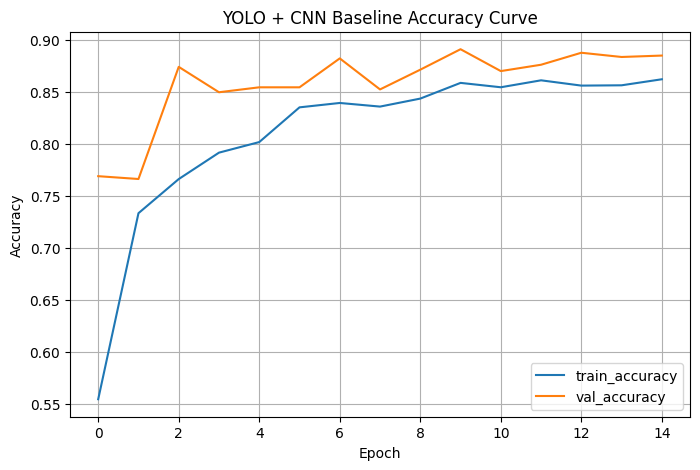

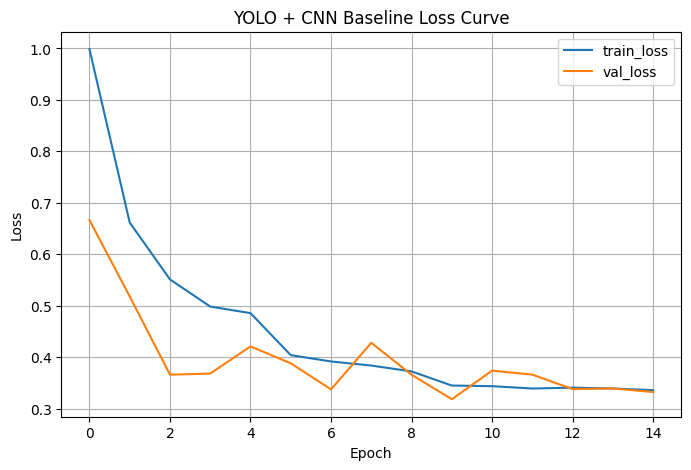

In [17]:
# 17. LEARNING CURVES

plt.figure(figsize=(8, 5))
plt.plot(history.history["accuracy"], label="train_accuracy")
plt.plot(history.history["val_accuracy"], label="val_accuracy")
plt.title("YOLO + CNN Baseline Accuracy Curve")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.savefig(f"{OUT_DIR}/accuracy_curve.png", dpi=150, bbox_inches="tight")
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="train_loss")
plt.plot(history.history["val_loss"], label="val_loss")
plt.title("YOLO + CNN Baseline Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.savefig(f"{OUT_DIR}/loss_curve.png", dpi=150, bbox_inches="tight")
plt.show()


In [18]:
# 18. EVALUATE TEST SET

test_loss, test_acc = model.evaluate(test_ds)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_acc)


47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.8873 - loss: 0.3243
Test Loss: 0.3243207037448883
Test Accuracy: 0.8873144388198853


In [19]:
# 19. PREDICT TEST SET

y_true = []

for _, y_batch in test_ds:
    y_true.extend(y_batch.numpy())

y_true = np.array(y_true)

pred_probs = model.predict(test_ds)
y_pred = np.argmax(pred_probs, axis=1)

print("y_true:", y_true.shape)
print("y_pred:", y_pred.shape)


47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step
y_true: (1482,)
y_pred: (1482,)


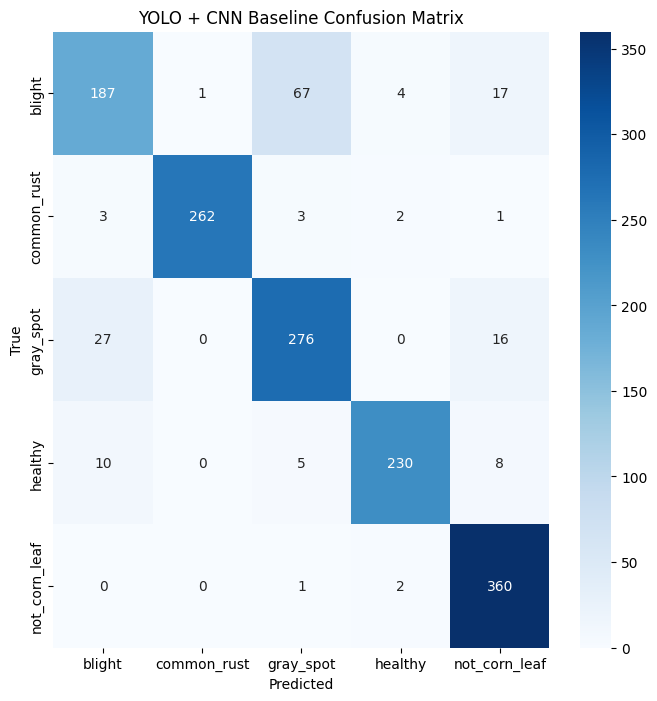

Saved: /kaggle/working/YOLO_CNN_Baseline_results/confusion_matrix.png


In [21]:
# 20. CONFUSION MATRIX

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 8))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES
)

plt.title("YOLO + CNN Baseline Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")

cm_path = f"{OUT_DIR}/confusion_matrix.png"
plt.savefig(cm_path, dpi=150, bbox_inches="tight")
plt.show()

print("Saved:", cm_path)


In [22]:
# 21. CLASSIFICATION REPORT

report_text = classification_report(
    y_true,
    y_pred,
    target_names=CLASS_NAMES
)

print(report_text)

report_dict = classification_report(
    y_true,
    y_pred,
    target_names=CLASS_NAMES,
    output_dict=True
)

report_df = pd.DataFrame(report_dict).transpose()

report_path = f"{OUT_DIR}/classification_report.csv"
report_df.to_csv(report_path)

print("Saved:", report_path)
report_df


               precision    recall  f1-score   support

       blight       0.82      0.68      0.74       276
  common_rust       1.00      0.97      0.98       271
    gray_spot       0.78      0.87      0.82       319
      healthy       0.97      0.91      0.94       253
not_corn_leaf       0.90      0.99      0.94       363

     accuracy                           0.89      1482
    macro avg       0.89      0.88      0.89      1482
 weighted avg       0.89      0.89      0.89      1482

Saved: /kaggle/working/YOLO_CNN_Baseline_results/classification_report.csv


,precision,recall,f1-score,support
blight,0.823789,0.677536,0.743539,276.000000
common_rust,0.996198,0.966790,0.981273,271.000000
gray_spot,0.784091,0.865204,0.822653,319.000000
healthy,0.966387,0.909091,0.936864,253.000000
not_corn_leaf,0.895522,0.991736,0.941176,363.000000
accuracy,0.887314,0.887314,0.887314,0.887314
macro avg,0.893197,0.882071,0.885101,1482.000000
weighted avg,0.888685,0.887314,0.885453,1482.000000


In [23]:
# 22. SAVE METRICS

metrics = {
    "model_name": MODEL_NAME,
    "test_loss": float(test_loss),
    "test_accuracy": float(test_acc),
    "classes": CLASS_NAMES,
    "img_size": IMG_SIZE,
    "batch_size": BATCH_SIZE,
    "epochs": EPOCHS,
    "yolo_model_path": YOLO_MODEL_PATH,
    "crop_dataset_dir": CROP_DATASET_DIR,
    "cnn_architecture": "Conv8-MaxPool-Conv16-MaxPool-Flatten-Dense32-Dropout0.5-Softmax"
}

metrics_path = f"{OUT_DIR}/metrics.json"

with open(metrics_path, "w", encoding="utf-8") as f:
    json.dump(metrics, f, indent=4, ensure_ascii=False)

print("Saved:", metrics_path)


Saved: /kaggle/working/YOLO_CNN_Baseline_results/metrics.json


In [20]:
# 23. ZIP RESULTS

zip_path = f"/kaggle/working/{MODEL_NAME}_results.zip"

shutil.make_archive(
    zip_path.replace(".zip", ""),
    "zip",
    OUT_DIR
)

print("Saved:", zip_path)


Saved: /kaggle/working/YOLO_CNN_Baseline_results.zip


In [25]:
# 24. OPTIONAL - TEST 1 IMAGE FROM COMPUTER

uploader = FileUpload(
    accept="image/*",
    multiple=True
)

display(uploader)


FileUpload(value=(), accept='image/*', description='Upload', multiple=True)

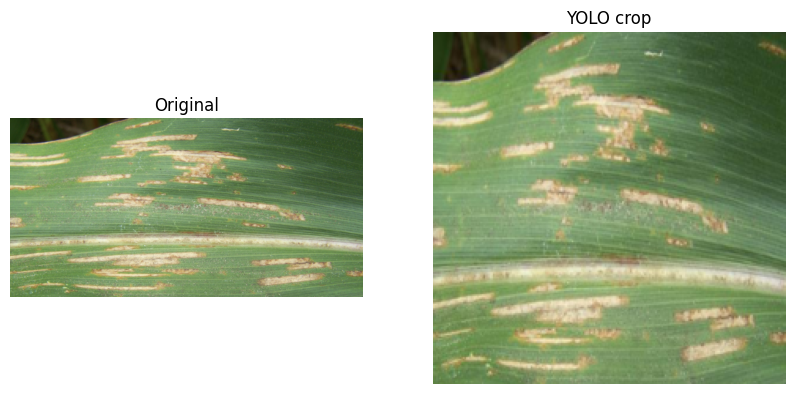

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
Prediction: blight
Confidence: 0.7114

All probabilities:
blight         : 0.7114
common_rust    : 0.0010
gray_spot      : 0.2242
healthy        : 0.0599
not_corn_leaf  : 0.0035


In [29]:
# 25. PREDICT UPLOADED IMAGE

uploaded = uploader.value[0]

img = Image.open(io.BytesIO(uploaded["content"])).convert("RGB")

temp_path = "/kaggle/working/temp_upload_image.jpg"
img.save(temp_path)

cropped = crop_with_yolo(
    image_path=temp_path,
    yolo_model=yolo_model,
    conf_thres=0.25,
    img_size=IMG_SIZE
)

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(img)
plt.title("Original")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(cropped)
plt.title("YOLO crop")
plt.axis("off")

plt.show()

x = np.array(cropped).astype("float32") / 255.0
x = np.expand_dims(x, axis=0)

pred = model.predict(x)[0]

pred_idx = int(np.argmax(pred))
confidence = float(pred[pred_idx])

print("Prediction:", CLASS_NAMES[pred_idx])
print("Confidence:", f"{confidence:.4f}")

print("\nAll probabilities:")
for cls, prob in zip(CLASS_NAMES, pred):
    print(f"{cls:15s}: {prob:.4f}")
